# 🔬 Colon Cancer Detection — Vision Transformer (ViT-B/16)

[![Python](https://img.shields.io/badge/Python-3.9+-blue.svg)](https://python.org)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.x-red.svg)](https://pytorch.org)
[![timm](https://img.shields.io/badge/timm-latest-green.svg)](https://github.com/huggingface/pytorch-image-models)

## 🎯 Objective
Binary classification of colon histopathology images:
- **Class 0 — `colon_aca`**: Colon Adenocarcinoma (malignant)
- **Class 1 — `colon_n`**: Colon Benign Tissue (healthy)

## 🗺️ Pipeline Overview
| Step | Description |
|------|-------------|
| 0 | GPU Setup & Verification |
| 1 | Library Installation |
| 2 | Dataset Mount & Verification |
| 3 | Imports & Hyperparameter Configuration |
| 4 | Data Augmentation & Dataset Preparation |
| 5 | DataLoaders + Sample Visualization |
| 6 | Pretrained ViT-B/16 Model Loading |
| 7 | Loss Function, Optimizer & LR Scheduler |
| 8 | Training Loop with Best-Model Checkpointing |
| 9 | Training Curves Visualization |
| 10 | Test Set Evaluation + Classification Report |
| 11 | Confusion Matrix |
| 12 | XAI — Attention Rollout Heatmaps |
| 13 | Model Saving & Download |
| 14 | Single-Image Inference |

---
> **Dataset**: [LC25000 Lung and Colon Histopathological Image Dataset](https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images) — 5,000 images per class @ 768×768px.  
> **Model**: ViT-Base/16 pretrained on ImageNet-21k, fine-tuned via transfer learning.


## ✅ Step 0 — GPU Setup & Verification

> **Required on Kaggle**: Go to **Settings** (right panel) → **Accelerator** → select **GPU T4 x2** → **Save**

This step confirms that a CUDA-enabled GPU is available. All heavy computation (training, XAI) runs on GPU. The model falls back to CPU automatically, but training will be ~20× slower.


In [1]:
import torch

# Confirm GPU availability
cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')

print('='*50)
print(f'  CUDA available : {cuda_available}')
if cuda_available:
    print(f'  GPU            : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'  Active device  : {device}')
print('='*50)

if not cuda_available:
    print('\n⚠️  WARNING: GPU not found. Go to Runtime → Change runtime type → T4 GPU.')


  CUDA available : True
  GPU            : Tesla T4
  VRAM           : 15.6 GB
  Active device  : cuda


## 📦 Step 1 — Library Installation

| Library | Purpose |
|---------|---------|
| `timm` | Pretrained ViT model (ViT-B/16) |
| `scikit-learn` | Metrics: classification report, confusion matrix |
| `matplotlib` / `seaborn` | Visualization — training curves, heatmaps |

> **Note**: On Kaggle, most libraries are pre-installed. `timm` is the only one that may need installing.


In [2]:
!pip install -q timm transformers scikit-learn matplotlib seaborn
print('✅ All libraries installed.')


✅ All libraries installed.


## 📁 Step 2 — Dataset Setup & Verification

### How to add your dataset on Kaggle:
1. Click **+ Add Data** (top right of the notebook editor)
2. Search for your dataset or upload it
3. Your zip file will be available at `/kaggle/input/<dataset-name>/`

### This step will:
- Auto-detect your zip file under `/kaggle/input/`
- Extract it to `/kaggle/working/dataset/`
- Verify the folder structure and image counts

### Expected folder structure after extraction:
```
/kaggle/working/dataset/
├── colon_aca/       ← Adenocarcinoma images
│   ├── colonca1.jpeg
│   └── ...
└── colon_n/         ← Benign tissue images
    ├── colonn1.jpeg
    └── ...
```

> **Tip**: If your zip contains a subfolder (e.g. `dataset/colon_aca/`), the script below handles that automatically.


In [3]:
import os
from google.colab import drive

# ── MOUNT GOOGLE DRIVE ─────────────────────────────
drive.mount('/content/drive')

# ── GOOGLE DRIVE DATASET PATH ──────────────────────
# Update this path to match your folder structure in Drive
DATA_DIR = '/content/drive/MyDrive/dataset'

print(f'📂 Using: {os.path.abspath(DATA_DIR)}')

# ── VERIFY DATASET ────────────────────────────────
print('\n📂 Dataset Verification')
print('='*50)

total_images = 0

classes = [
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
]

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
    ]

    print(f'📁 {cls}: {len(images)} images')
    total_images += len(images)

print('='*50)
print(f'✅ Total: {total_images} images')

Mounted at /content/drive
📂 Using: /content/drive/MyDrive/dataset

📂 Dataset Verification
📁 colon_aca: 5002 images
📁 colon_n: 5000 images
✅ Total: 10002 images


## 🔧 Step 3 — Imports & Hyperparameter Configuration

All hyperparameters are centralised here. Modify these values to experiment:

| Parameter | Default | Notes |
|-----------|---------|-------|
| `IMG_SIZE` | 224 | ViT-B/16 requires 224×224 input |
| `BATCH_SIZE` | 32 | Reduce to 16 if GPU OOM |
| `NUM_EPOCHS` | 10 | Increase to 20 for better results |
| `LR` | 2e-4 | AdamW learning rate |
| `TRAIN_RATIO` | 0.70 | 70% of data for training |
| `VAL_RATIO` | 0.15 | 15% validation, 15% test |

> **Kaggle note**: `DATA_DIR` is set automatically from Step 2. Do not change it unless you extracted manually.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import warnings, os, json
warnings.filterwarnings('ignore')

# ── KAGGLE DATA PATH (set automatically by Step 2) ────────────────────────────
# DATA_DIR is already defined above from the extraction step.
# If you skipped Step 2 or extracted manually, set it here:
# DATA_DIR = '/kaggle/working/dataset'   # ← uncomment & edit if needed

# ── HYPERPARAMETERS ────────────────────────────────────────────────────────────
IMG_SIZE     = 224        # ViT requires 224×224 input
BATCH_SIZE   = 32         # reduce to 16 if you get CUDA OOM errors
NUM_EPOCHS   = 10         # training iterations over the full dataset
LR           = 2e-4       # initial learning rate (AdamW)
WEIGHT_DECAY = 1e-4       # L2 regularisation
TRAIN_RATIO  = 0.70       # 70% train
VAL_RATIO    = 0.15       # 15% validation  →  15% test (remainder)
SEED         = 42         # reproducibility seed

# ── REPRODUCIBILITY ────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── OUTPUT DIR (Kaggle working directory) ──────────────────────────────────────
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Configuration loaded')
print(f'   Device      : {device}')
print(f'   Data dir    : {DATA_DIR}')
print(f'   Output dir  : {OUTPUT_DIR}')
print(f'   Image size  : {IMG_SIZE}×{IMG_SIZE}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Epochs      : {NUM_EPOCHS}')
print(f'   LR          : {LR}')
print(f'   Split       : {int(TRAIN_RATIO*100)}% / {int(VAL_RATIO*100)}% / {int((1-TRAIN_RATIO-VAL_RATIO)*100)}%')


✅ Configuration loaded
   Device      : cuda
   Data dir    : /content/drive/MyDrive/dataset
   Output dir  : /kaggle/working
   Image size  : 224×224
   Batch size  : 32
   Epochs      : 10
   LR          : 0.0002
   Split       : 70% / 15% / 15%


## 🖼️ Step 4 — Data Augmentation & Dataset Preparation

### Why augmentation?
The model sees each image from different angles / lighting during training, which improves generalisation and reduces overfitting.

| Augmentation | Applied To | Why |
|---|---|---|
| `RandomHorizontalFlip` | Train only | Histopathology has no canonical orientation |
| `RandomVerticalFlip` | Train only | Same reason |
| `RandomRotation(15°)` | Train only | Simulates slide orientation variation |
| `ColorJitter` | Train only | Compensates for stain variation between labs |
| `Normalize` (ImageNet stats) | Train + Val/Test | Required for pretrained ViT |

> **No augmentation** is applied to validation and test sets — we want a clean, unbiased evaluation.

### Dataset split strategy
We use **random_split** with a fixed seed for full reproducibility. A `SubsetWithTransform` wrapper ensures val/test subsets use the clean (no-augmentation) transforms, even though they share the same underlying `ImageFolder` object.


In [5]:
# ── TRANSFORMS ────────────────────────────────────────────────────────────────
# Training: augmentation to improve generalisation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # ImageNet normalisation — required for pretrained ViT
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation / Test: no augmentation, only resize + normalise
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── DATASET LOADING ────────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
class_names  = full_dataset.classes   # ['colon_aca', 'colon_n'] (alphabetical)
num_classes  = len(class_names)

print(f'Classes  : {class_names}')
print(f'Num imgs : {len(full_dataset):,}')

# ── TRAIN / VAL / TEST SPLIT ──────────────────────────────────────────────────
n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# ── SubsetWithTransform wrapper ────────────────────────────────────────────────
# Applies eval_transforms to val/test (no augmentation) while reusing the split indices.
class SubsetWithTransform(Dataset):
    """Wraps a Subset and overrides its transform with a custom one."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        path, label = self.subset.dataset.imgs[self.subset.indices[idx]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

val_set_clean  = SubsetWithTransform(val_set,  eval_transforms)
test_set_clean = SubsetWithTransform(test_set, eval_transforms)

print(f'\nSplit (seed={SEED}):')
print(f'  Train : {n_train:,} images ({TRAIN_RATIO*100:.0f}%)')
print(f'  Val   : {n_val:,} images ({VAL_RATIO*100:.0f}%)')
print(f'  Test  : {n_test:,} images ({(1-TRAIN_RATIO-VAL_RATIO)*100:.0f}%)')
print('✅ Datasets ready.')


Classes  : ['colon_aca', 'colon_n']
Num imgs : 10,002

Split (seed=42):
  Train : 7,001 images (70%)
  Val   : 1,500 images (15%)
  Test  : 1,501 images (15%)
✅ Datasets ready.


## 🚀 Step 5 — DataLoaders & Sample Visualization

`DataLoader` wraps the dataset to produce mini-batches. Key settings:
- **`shuffle=True`** for training: ensures random mini-batch order each epoch.
- **`num_workers=2`**: parallel data loading (reduces GPU idle time).
- **`pin_memory=True`**: speeds up CPU→GPU transfer.


Train batches : 219
Val batches   : 47
Test batches  : 47
✅ DataLoaders ready.


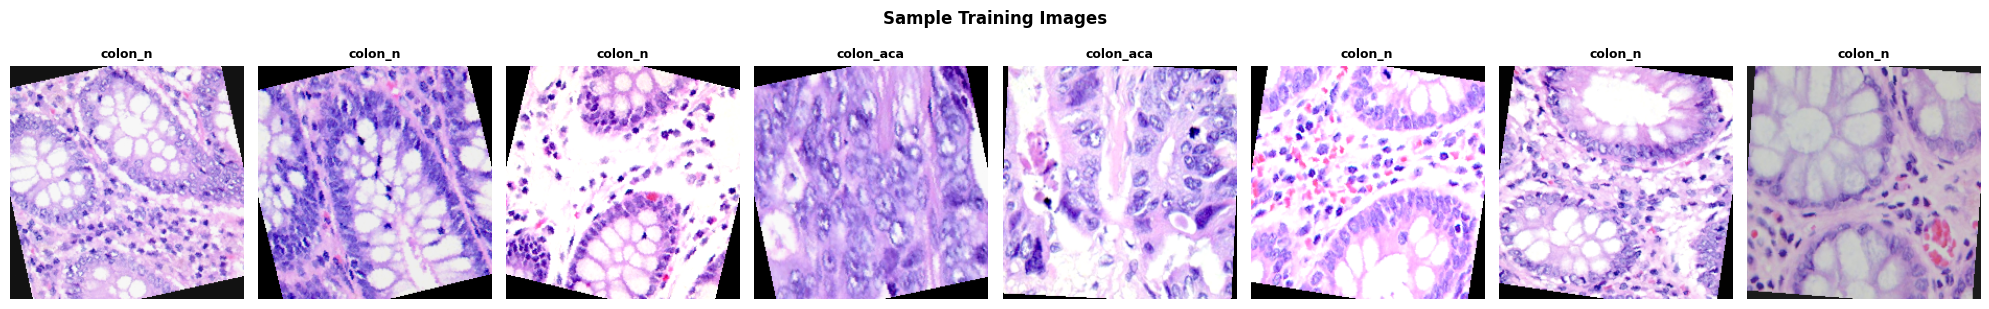

In [6]:
# ── DATALOADERS ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_set,      batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set_clean,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set_clean, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print('✅ DataLoaders ready.')

# ── SAMPLE VISUALISATION ──────────────────────────────────────────────────────
def visualise_batch(loader, class_names, n=8, title='Sample Training Images'):
    """Display a grid of n images from the first batch of a DataLoader."""
    imgs, labels = next(iter(loader))
    # Reverse ImageNet normalisation for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    imgs = (imgs[:n] * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1, 2, 0).numpy())
        ax.set_title(class_names[labels[i]], fontsize=9, fontweight='bold')
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualise_batch(train_loader, class_names)


## 🤖 Step 6 — Pretrained ViT-B/16 Model

### What is ViT-B/16?
Vision Transformer Base with 16×16 patch size. Instead of convolutions, the image is divided into a grid of 14×14 patches (16×16 px each). Each patch is flattened and treated as a "token" — just like words in a sentence — fed into a 12-layer Transformer encoder.

```
Input Image (224×224)
      ↓ split into 196 patches of 16×16
Patch Embedding (196 tokens + 1 CLS token = 197 tokens)
      ↓
12× Transformer Encoder Block
   ├── Multi-Head Self-Attention (12 heads)
   └── MLP (Feed-Forward Network)
      ↓
CLS Token → Linear Classification Head → 2 classes
```

### Transfer Learning
We load weights pretrained on ImageNet-1k (86M parameters). Only the final linear head is randomly initialised with 2 output neurons (one per class). Fine-tuning the full model typically gives the best results for medical imaging.

### Optional: Freeze Backbone
If your dataset is small (< 2k images per class), set `FREEZE_BACKBONE = True` to train only the last 4 Transformer blocks + head, reducing risk of overfitting.


In [7]:
# ── LOAD PRETRAINED ViT-B/16 ──────────────────────────────────────────────────
FREEZE_BACKBONE = False   # set True if dataset is small (< 2k images / class)

model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,         # load ImageNet pretrained weights
    num_classes=num_classes  # replace final head: 1000 → 2
)

if FREEZE_BACKBONE:
    # Freeze all layers except last 4 transformer blocks + head + norm
    unfreeze_keywords = ['blocks.8', 'blocks.9', 'blocks.10', 'blocks.11',
                         'head', 'norm']
    for name, param in model.named_parameters():
        param.requires_grad = any(kw in name for kw in unfreeze_keywords)
    print('🔒 Backbone frozen — training last 4 blocks + head only.')

model = model.to(device)

# ── PARAMETER COUNT ────────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('Model: ViT-Base/16 (ImageNet pretrained)')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')
print(f'  Frozen parameters    : {frozen_params:,}')
print(f'  Classification head  : {model.head}')
print('✅ Model ready.')


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model: ViT-Base/16 (ImageNet pretrained)
  Total parameters     : 85,800,194
  Trainable parameters : 85,800,194
  Frozen parameters    : 0
  Classification head  : Linear(in_features=768, out_features=2, bias=True)
✅ Model ready.


## ⚙️ Step 7 — Loss Function, Optimizer & LR Scheduler

| Component | Choice | Reason |
|---|---|---|
| **Loss** | `CrossEntropyLoss` | Standard for multi-class classification |
| **Optimizer** | `AdamW` | Adam + decoupled weight decay; standard for Transformers |
| **Scheduler** | `CosineAnnealingLR` | Smooth LR decay prevents abrupt convergence |

### Learning Rate Schedule (Cosine Annealing)
LR decays smoothly from `LR` to `eta_min=1e-6` over `NUM_EPOCHS`:

```
LR ─┐                          ← epoch 1
    ╲_____                     ← epoch ~5
          ─────── → 1e-6       ← epoch NUM_EPOCHS
```
This avoids the hard LR drops of step schedulers and often yields better final accuracy.


In [8]:
# ── LOSS FUNCTION ─────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

# ── OPTIMIZER ─────────────────────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── LR SCHEDULER ──────────────────────────────────────────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print('✅ Loss / Optimizer / Scheduler configured.')
print(f'   Optimizer  : AdamW (lr={LR}, wd={WEIGHT_DECAY})')
print(f'   Scheduler  : CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min=1e-6)')


✅ Loss / Optimizer / Scheduler configured.
   Optimizer  : AdamW (lr=0.0002, wd=0.0001)
   Scheduler  : CosineAnnealingLR (T_max=10, eta_min=1e-6)


## 🏋️ Step 8 — Training Loop

### What happens each epoch?
1. **Forward pass**: batch of images → model → class logits
2. **Loss computation**: CrossEntropy(logits, true labels)
3. **Backward pass**: compute gradients via backpropagation
4. **Optimizer step**: update weights using AdamW
5. **Validation**: evaluate on validation set (no gradient computation)
6. **Scheduler step**: update learning rate

The **best model** (highest validation accuracy) is saved to disk at each improvement, so the final checkpoint is not just the last epoch's weights.


In [9]:
import torch
import os
from torch.cuda.amp import autocast, GradScaler

# ── DEVICE SETUP ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# Move model + loss to GPU
model = model.to(device)
criterion = criterion.to(device)

# Mixed precision scaler (for faster GPU training)
scaler = GradScaler()

# ── TRAIN ONE EPOCH ────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():  # ✅ GPU acceleration
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


# ── EVALUATION ────────────────────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


# ── TRAINING LOOP ─────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': []
}

best_val_acc = 0.0
best_model_path = os.path.join(OUTPUT_DIR, 'best_colon_vit.pth')

print(f'Training ViT-B/16 for {NUM_EPOCHS} epochs on {device}')
print('='*72)
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} |')
print('-'*72)

for epoch in range(1, NUM_EPOCHS + 1):

    # Train + Validate
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Store history
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Save best model
    saved = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        saved = '  ✅ saved'

    print(f'{epoch:>5d} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{vl_loss:>8.4f} | {vl_acc*100:>6.2f}%{saved}')

print('='*72)
print(f'✅ Best Validation Accuracy : {best_val_acc*100:.2f}%')
print(f'✅ Best model saved to      : {best_model_path}')

✅ Using device: cuda
Training ViT-B/16 for 10 epochs on cuda
Epoch | Train Loss | Train Acc | Val Loss | Val Acc |
------------------------------------------------------------------------
    1 |     0.5425 |    71.58% |   0.0956 |  96.53%  ✅ saved
    2 |     0.1219 |    95.09% |   0.0311 |  98.87%  ✅ saved
    3 |     0.0728 |    97.13% |   0.0075 |  99.73%  ✅ saved
    4 |     0.0329 |    98.81% |   0.0110 |  99.53%
    5 |     0.0256 |    99.00% |   0.0022 |  99.93%  ✅ saved
    6 |     0.0341 |    98.80% |   0.0048 |  99.87%
    7 |     0.0107 |    99.64% |   0.0042 |  99.87%
    8 |     0.0050 |    99.81% |   0.0032 |  99.93%
    9 |     0.0041 |    99.86% |   0.0002 | 100.00%  ✅ saved
   10 |     0.0022 |    99.94% |   0.0011 |  99.93%
✅ Best Validation Accuracy : 100.00%
✅ Best model saved to      : /kaggle/working/best_colon_vit.pth


In [19]:
import json, os
from google.colab import drive

# Mount Drive if not already mounted
drive.mount('/content/drive', force_remount=False)

# Save to Google Drive
OUTPUT_DIR = '/content/drive/MyDrive/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

checkpoint = {
    'model_state_dict' : model.state_dict(),
    'class_names'      : class_names,
    'num_classes'      : num_classes,
    'best_val_accuracy': round(best_val_acc, 4),
    'test_accuracy'    : round(test_acc, 4),
    'config': {
        'model'       : 'vit_base_patch16_224',
        'img_size'    : IMG_SIZE,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'lr'          : LR,
        'weight_decay': WEIGHT_DECAY,
        'seed'        : SEED,
        'task'        : 'colon_binary_classification'
    }
}

save_path = os.path.join(OUTPUT_DIR, 'colon_cancer_vit_final.pth')
torch.save(checkpoint, save_path)
print(f'✅ Colon model saved to: {save_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Colon model saved to: /content/drive/MyDrive/models/colon_cancer_vit_final.pth


## 📈 Step 9 — Training Curves Visualization

Plot loss and accuracy over epochs for both train and validation sets.

**What to look for:**
- 📉 Both train and val loss should decrease. If val loss rises while train loss falls → **overfitting**.
- 📈 Both accuracies should increase. A large train–val gap → overfitting.
- If both are stuck → **underfitting** (try more epochs or lower LR).


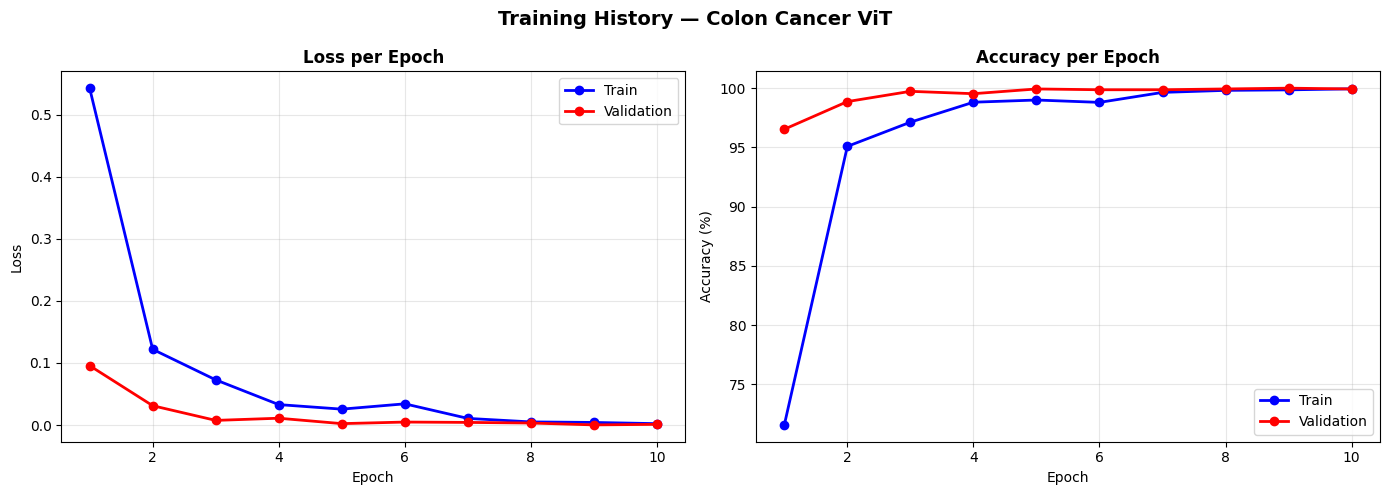

Saved: training_curves.png
Saved to /kaggle/working/training_curves.png


In [12]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Colon Cancer ViT', fontsize=14, fontweight='bold')

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation', linewidth=2)
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train', linewidth=2)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Validation', linewidth=2)
ax2.set_title('Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

print(f'Saved to {OUTPUT_DIR}/training_curves.png')

## 🧪 Step 10 — Test Set Evaluation

We load the **best checkpoint** (highest validation accuracy) and evaluate on the held-out test set.

**Metrics explained:**
| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Overall correctness |
| Precision | TP/(TP+FP) | Of all predicted positives, how many were correct? |
| Recall | TP/(TP+FN) | Of all actual positives, how many did we find? |
| F1-Score | 2×P×R/(P+R) | Harmonic mean of Precision and Recall |

> In medical imaging, **Recall (Sensitivity)** for the cancer class is often the most important metric — missing a cancer (False Negative) is more dangerous than a false alarm.


In [11]:
# Load the best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu()
        preds   = probs.argmax(dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean()

print('='*55)
print(f'  Test Set Accuracy : {test_acc*100:.2f}%')
print('='*55)
print()
print('Detailed Classification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


  Test Set Accuracy : 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

   colon_aca     1.0000    1.0000    1.0000       767
     colon_n     1.0000    1.0000    1.0000       734

    accuracy                         1.0000      1501
   macro avg     1.0000    1.0000    1.0000      1501
weighted avg     1.0000    1.0000    1.0000      1501



## 📊 Step 11 — Confusion Matrix

The confusion matrix shows exactly which classes the model confuses.

```
                  Predicted
                 ACA    Benign
Actual ACA   [  TP      FN  ]
       Benign [  FP      TN  ]
```

- **Diagonal** (TP, TN): correct predictions
- **Off-diagonal** (FP, FN): errors — important to inspect in medical contexts


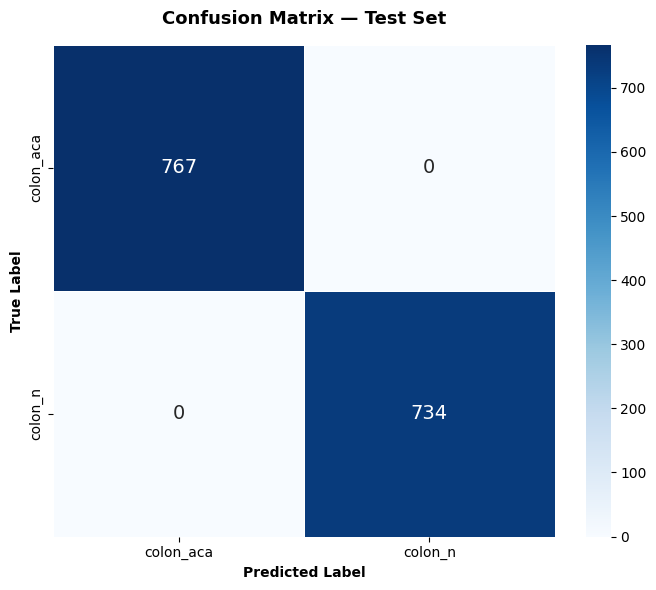

Per-class accuracy:
  colon_aca: 767/767 = 100.00%
  colon_n: 734/734 = 100.00%
Saved to /kaggle/working/confusion_matrix.png


In [13]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 14}, ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold', fontsize=13, pad=15)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print('Per-class accuracy:')
for i, cls in enumerate(class_names):
    cls_correct = cm[i, i]
    cls_total   = cm[i].sum()
    print(f'  {cls}: {cls_correct}/{cls_total} = {cls_correct/cls_total*100:.2f}%')
print(f'Saved to {OUTPUT_DIR}/confusion_matrix.png')


## 🔍 Step 12 — Explainability: Attention Rollout Heatmaps (XAI)

### What is Attention Rollout?
ViTs compute **self-attention** at each of the 12 Transformer layers. Each token attends to all other tokens. Attention Rollout propagates these attention weights layer-by-layer to identify which image **patches** the model focused on when making a prediction.

**Algorithm:**
1. Capture attention matrices `A_1, A_2, ..., A_12` from all layers via forward hooks
2. Add the identity matrix to each (to model residual connections)
3. Normalise row-wise
4. Multiply them: `Rollout = A_12 × A_11 × ... × A_1`
5. Extract the CLS token row → 196 attention weights → reshape to 14×14 grid → overlay on image

**Why is this useful?**
It provides a human-interpretable explanation of **where** the model is "looking", which is crucial for clinical trust.


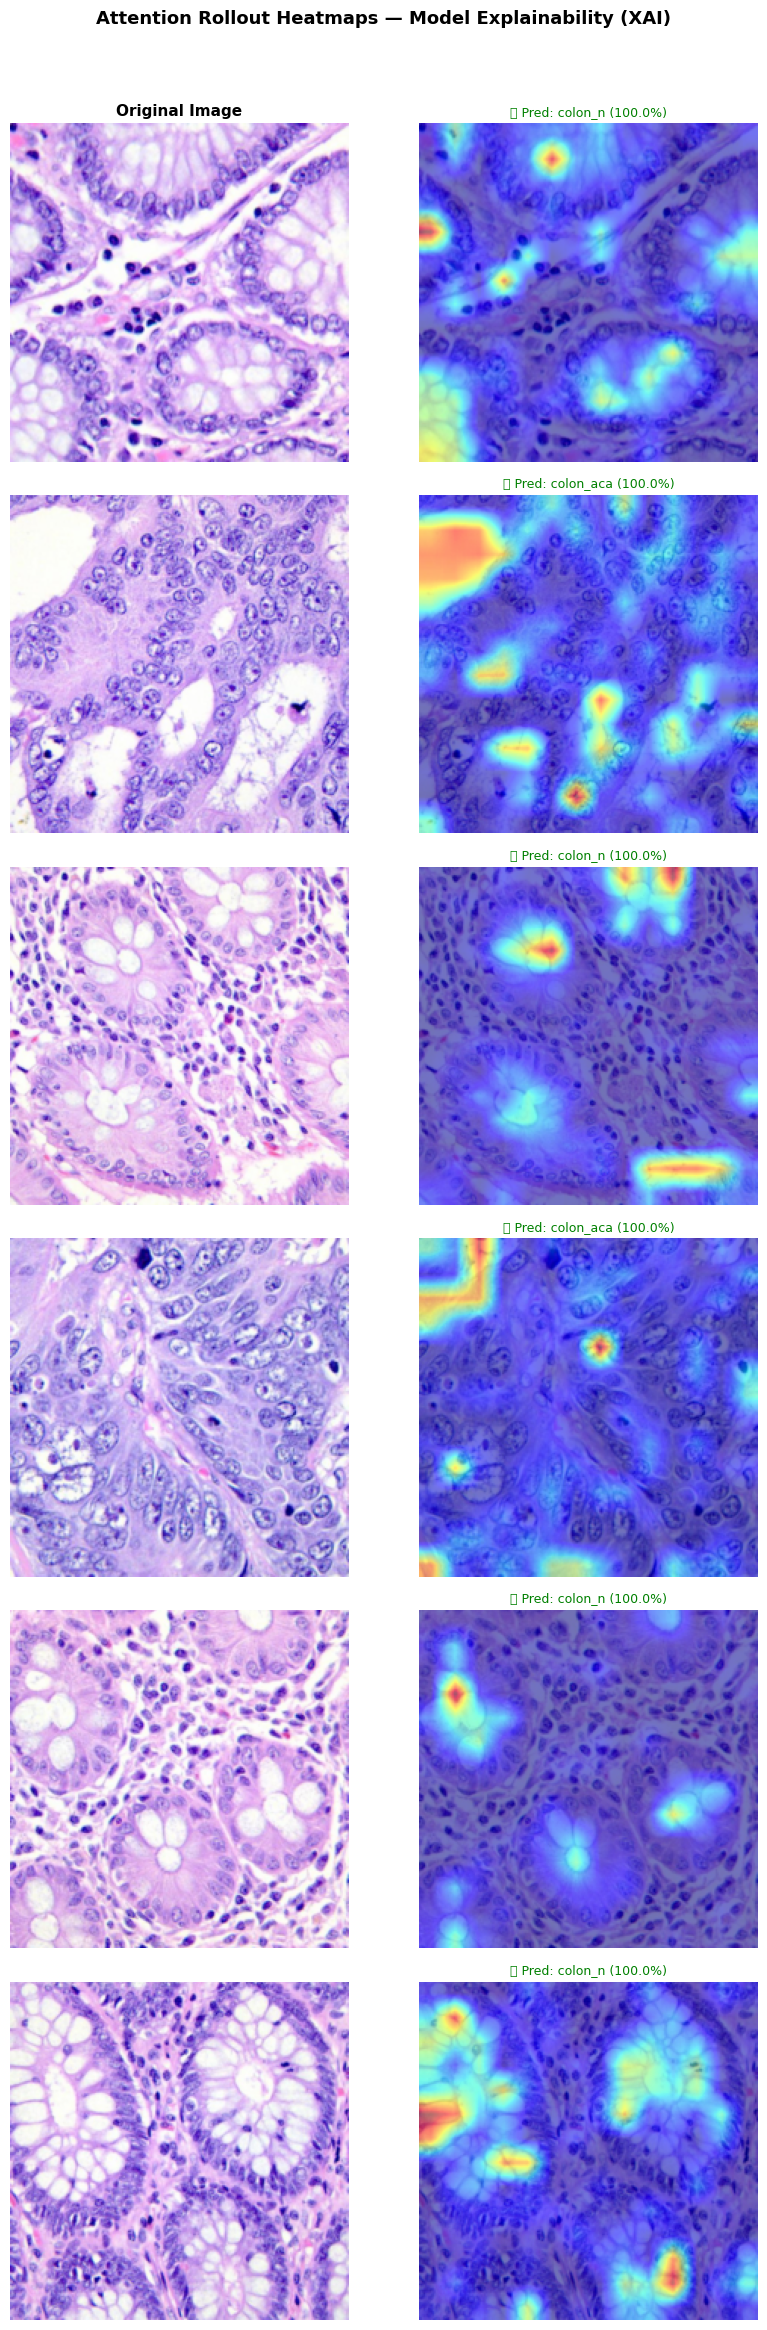

Saved to /kaggle/working/attention_heatmaps.png


In [14]:
def compute_attention_rollout(model, img_tensor, device,
                              head_fusion='mean', discard_ratio=0.9):
    """
    Compute Attention Rollout for a single image.

    Args:
        model         : trained timm ViT model
        img_tensor    : (C, H, W) normalised tensor
        device        : torch device
        head_fusion   : 'mean' | 'min' | 'max' — multi-head fusion strategy
        discard_ratio : fraction of lowest-attention values to zero out (noise filter)

    Returns:
        mask       : (H, W) attention map in [0, 1]
        pred_class : int — predicted class index
        confidence : float — softmax confidence
    """
    model.eval()
    attention_maps = []

    def hook_fn(module, inp, out):
        # Recompute attention from Q, K (timm ViT's attn_drop discards weights)
        B, N, C = inp[0].shape
        qkv = module.qkv(inp[0]).reshape(
            B, N, 3, module.num_heads, C // module.num_heads
        ).permute(2, 0, 3, 1, 4)
        q, k, _ = qkv.unbind(0)
        scale = (C // module.num_heads) ** -0.5
        attn  = (q @ k.transpose(-2, -1)) * scale
        attn  = attn.softmax(dim=-1).detach().cpu()
        attention_maps.append(attn)

    hooks = [block.attn.register_forward_hook(hook_fn) for block in model.blocks]

    with torch.no_grad():
        out        = model(img_tensor.unsqueeze(0).to(device))
        pred_class = out.argmax(1).item()
        confidence = torch.softmax(out, dim=1).max().item()

    for h in hooks:
        h.remove()

    # Rollout
    rollout = torch.eye(attention_maps[0].shape[-1])
    for attn in attention_maps:
        if   head_fusion == 'mean': fused = attn.mean(1)[0]
        elif head_fusion == 'min':  fused = attn.min(1).values[0]
        else:                       fused = attn.max(1).values[0]

        # Discard lowest attentions
        thresh = torch.quantile(fused.view(-1), discard_ratio)
        fused[fused < thresh] = 0

        fused = fused + torch.eye(fused.shape[0])
        fused = fused / fused.sum(dim=-1, keepdim=True)
        rollout = fused @ rollout

    # CLS token → patch tokens → 14×14 grid
    mask = rollout[0, 1:]
    gs   = int(mask.shape[0] ** 0.5)
    mask = mask.reshape(gs, gs).numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask, pred_class, confidence


def show_attention_heatmaps(model, dataset, class_names, device, num_samples=6):
    """Display original image side-by-side with its attention rollout heatmap."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 2, figsize=(9, num_samples * 3.8))
    fig.suptitle('Attention Rollout Heatmaps — Model Explainability (XAI)',
             fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # push content down to make room for title
    axes[0, 0].set_title('Original Image',    fontweight='bold', fontsize=11)
    axes[0, 1].set_title('Attention Rollout', fontweight='bold', fontsize=11)

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        mask, pred_class, conf = compute_attention_rollout(model, img_tensor, device)

        # Denormalize for display
        img_np = np.clip(img_tensor.permute(1, 2, 0).numpy() * std + mean, 0, 1)

        # Upsample mask to image size
        mask_up = np.array(
            Image.fromarray((mask * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR
            )
        ) / 255.0

        correct = pred_class == true_label
        color   = 'green' if correct else 'red'
        status  = '✅' if correct else '❌'

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(f'True: {class_names[true_label]}', fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(mask_up, alpha=0.55, cmap='jet')
        axes[row, 1].set_title(
            f'{status} Pred: {class_names[pred_class]} ({conf*100:.1f}%)',
            fontsize=9, color=color
        )
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'attention_heatmaps.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {OUTPUT_DIR}/attention_heatmaps.png')


show_attention_heatmaps(model, test_set_clean, class_names, device, num_samples=6)


## 💾 Step 13 — Save Model Checkpoint

The checkpoint includes model weights AND all metadata (class names, config, metrics) needed to reload the model later.

### Where are my files on Kaggle?
All outputs are saved to `/kaggle/working/`. To download them:
1. After the notebook finishes, go to the **Output** tab (right panel)
2. Click the download icon next to any file

Files saved:
- `best_colon_vit.pth` — best checkpoint (saved during training)
- `colon_cancer_vit_final.pth` — final checkpoint with full metadata
- `training_curves.png`
- `confusion_matrix.png`
- `attention_heatmaps.png`
- `metrics_colon.json`


In [15]:
import json

checkpoint = {
    'model_state_dict' : model.state_dict(),
    'class_names'      : class_names,
    'num_classes'      : num_classes,
    'best_val_accuracy': round(best_val_acc, 4),
    'test_accuracy'    : round(test_acc, 4),
    'config': {
        'model'       : 'vit_base_patch16_224',
        'img_size'    : IMG_SIZE,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'lr'          : LR,
        'weight_decay': WEIGHT_DECAY,
        'seed'        : SEED,
        'task'        : 'colon_binary_classification'
    }
}

save_path = os.path.join(OUTPUT_DIR, 'colon_cancer_vit_final.pth')
torch.save(checkpoint, save_path)
print(f'✅ Checkpoint saved: {save_path}')

# Save metrics as JSON
metrics = {
    'best_val_accuracy': round(best_val_acc * 100, 2),
    'test_accuracy'    : round(test_acc * 100, 2),
    'class_names'      : class_names,
}
metrics_path = os.path.join(OUTPUT_DIR, 'metrics_colon.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'✅ Metrics saved: {metrics_path}')

# ── LIST ALL OUTPUT FILES ──────────────────────────────────────────────────────
print(f'\n📁 All files saved to {OUTPUT_DIR}:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'   {fname:<40s}  {size_kb:>8.1f} KB')

print('\n✅ Go to the Output tab (right panel) to download your files.')


✅ Checkpoint saved: /kaggle/working/colon_cancer_vit_final.pth
✅ Metrics saved: /kaggle/working/metrics_colon.json

📁 All files saved to /kaggle/working:
   attention_heatmaps.png                      4706.1 KB
   best_colon_vit.pth                        335215.7 KB
   colon_cancer_vit_final.pth                335217.6 KB
   confusion_matrix.png                          39.4 KB
   metrics_colon.json                             0.1 KB
   training_curves.png                           80.7 KB

✅ Go to the Output tab (right panel) to download your files.


## 🔮 Step 14 — Single-Image Inference

Run the trained model on any individual image from your dataset.

**On Kaggle**, pick any image path directly from the extracted dataset — no upload dialog needed.


Running inference on: /content/drive/MyDrive/dataset/colon_aca/colonca4522.jpeg

🔬 Image      : colonca4522.jpeg
🎯 Prediction : colon_aca (100.0%)

Per-class probabilities:
   colon_aca             100.0%  ███████████████████████████████████████
   colon_n                 0.0%  


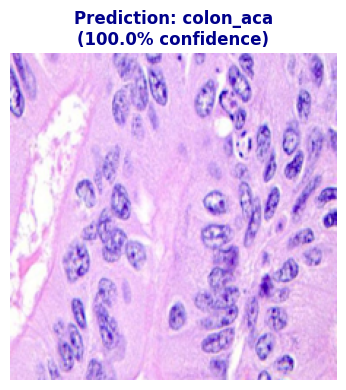

In [16]:
def predict_single_image(model, image_path, class_names, device, img_size=224):
    """
    Run inference on a single image file.

    Args:
        model       : trained model (on device)
        image_path  : path to image file (.jpg, .jpeg, .png)
        class_names : list of class label strings
        device      : torch device
        img_size    : input size expected by the model
    """
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    pil_img    = Image.open(image_path).convert('RGB')
    img_tensor = transform(pil_img)

    model.eval()
    with torch.no_grad():
        out   = model(img_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0].cpu().numpy()

    pred_class = probs.argmax()

    print(f'\n🔬 Image      : {os.path.basename(image_path)}')
    print(f'🎯 Prediction : {class_names[pred_class]} ({probs[pred_class]*100:.1f}%)')
    print('\nPer-class probabilities:')
    for i, name in enumerate(class_names):
        bar = '█' * int(probs[i] * 40)
        print(f'   {name:20s}  {probs[i]*100:5.1f}%  {bar}')

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(pil_img.resize((img_size, img_size)))
    ax.set_title(f'Prediction: {class_names[pred_class]}\n({probs[pred_class]*100:.1f}% confidence)',
                 fontweight='bold', color='darkblue')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── PICK ANY IMAGE FROM YOUR EXTRACTED DATASET ────────────────────────────────
# This picks the first image from the first class folder automatically.
# Change img_path to any image file you want to test.
import glob as _glob

sample_imgs = _glob.glob(os.path.join(DATA_DIR, '*', '*.jpeg')) + \
              _glob.glob(os.path.join(DATA_DIR, '*', '*.jpg'))  + \
              _glob.glob(os.path.join(DATA_DIR, '*', '*.png'))

if sample_imgs:
    img_path = sample_imgs[0]   # ← change index or hardcode a path to test a specific image
    print(f'Running inference on: {img_path}')
    predict_single_image(model, img_path, class_names, device)
else:
    print('⚠️  No images found. Check that DATA_DIR is correct.')
    print(f'   DATA_DIR = {DATA_DIR}')
